In [1]:
# ------------------ IMPORT LIBRARIES ------------------
import pandas as pd
import numpy as np
import re
import nltk
import shap
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

# ------------------ SETUP ------------------
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\prash\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\prash\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\prash\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\prash\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [5]:
# ------------------ LOAD DATA ------------------
df = pd.read_csv("D:/University/Project/Proj/Processed/yelp_restaurent_data.csv")

# ------------------ LABEL ENCODING ------------------
categorical_cols = ['state', 'city', 'generalized_category', 'Alcohol', 'RestaurantsAttire',
                    'Ambience', 'NoiseLevel', 'GoodForMeal', 'Music', 'BestNights',
                    'BYOBCorkage', 'HairSpecializesIn', 'AgesAllowed',
                    'DietaryRestrictions', 'WiFi', 'Smoking']
label_enc = LabelEncoder()
for col in categorical_cols:
    if col in df.columns:
        df[col] = label_enc.fit_transform(df[col].astype(str))
df.fillna(0, inplace=True)

In [ ]:
# ------------------ EARLY REVIEW AGGREGATION ------------------
df = df.sort_values(['business_id', 'date'])
early_reviews = df.groupby('business_id').head(20)  # First 5 reviews per business

# Aggregation logic
aggregation = {}
for col in early_reviews.columns:
    if col == 'text':
        aggregation[col] = lambda x: " ".join(x.astype(str))
    elif col == 'stars':
        aggregation[col] = 'mean'
    elif col in ['useful', 'funny', 'cool']:
        aggregation[col] = 'sum'
    elif col == 'date':
        aggregation[col] = 'min'
    elif col == 'business_id':
        continue
    else:
        aggregation[col] = 'first'

df = early_reviews.groupby('business_id').agg(aggregation).reset_index()


In [7]:
# ------------------ TEXT CLEANING ------------------
nltk.download('punkt_tab')
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

df['cleaned_text'] = df['text'].apply(clean_text)

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Dheeraj\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [9]:
# ------------------ FEATURE ENGINEERING ------------------
analyzer = SentimentIntensityAnalyzer()
nltk.download('averaged_perceptron_tagger_eng')
df['sentiment_score'] = df['text'].apply(lambda x: analyzer.polarity_scores(str(x))['compound'])
df['review_length'] = df['text'].apply(lambda x: len(str(x).split()))
df['adj_adv_count'] = df['text'].apply(lambda x: sum(1 for word, tag in pos_tag(word_tokenize(str(x))) if tag in ['JJ','JJR','JJS','RB','RBR','RBS']))
df['funny_votes'] = df['funny']
df['useful_votes'] = df['useful']
df['cool_votes'] = df['cool']

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Dheeraj\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


In [11]:
# ------------------ SAVE PROCESSED DATA ------------------
df.to_csv("yelp_reviews_feature_engineered.csv", index=False)
print("Dataset saved to 'yelp_reviews_feature_engineered.csv'")

✅ Dataset saved to 'yelp_reviews_feature_engineered.csv'


In [13]:
# ------------------ LABEL CREATION ------------------
df['label_stars'] = df['stars_x'].astype(float)
df['label_bucket'] = df['stars_x'].round().astype(int)

# ------------------ TF-IDF ------------------
tfidf = TfidfVectorizer(max_features=100)
tfidf_matrix = tfidf.fit_transform(df['cleaned_text'])
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf.get_feature_names_out())
df = df.reset_index(drop=True).join(tfidf_df)


In [17]:
# ------------------ FAKE REVIEW FEATURES ------------------
df['same_reviewer'] = df.duplicated(['user_id'], keep=False).astype(int)
df['repeated_phrases'] = df['text'].apply(lambda x: int(any(x.count(word) > 1 for word in set(str(x).split()))))
df['burst_review'] = df['date'].astype(str).duplicated(keep=False).astype(int)


In [19]:
df.to_csv("yelp_reviews_with_fake_review_features.csv", index=False)
print("✅ Dataset saved as CSV.")

✅ Dataset saved as CSV.


In [16]:
# Import libraries
from sklearn.model_selection import train_test_split
import pandas as pd

# Define your target y
y = df["label_bucket"].astype(int)

# Define X by dropping unwanted columns
drop_cols = [
    'review_id', 'user_id', 'business_id', 'text', 'cleaned_text', 'stars_x',
    'label_stars', 'name', 'hours', 'date', 'label_bucket', 'address', 'postal_code'
]
X = df.drop(columns=drop_cols, errors='ignore')

# List of columns with True/False strings
bool_cols = [
    'ByAppointmentOnly',
    'BusinessAcceptsCreditCards',
    'BikeParking',
    'CoatCheck',
    'RestaurantsTakeOut',
    'RestaurantsDelivery',
    'Caters',
    'BusinessParking',
    'WheelchairAccessible',
    'HappyHour',
    'OutdoorSeating',
    'HasTV',
    'RestaurantsReservations',
    'DogsAllowed',
    'GoodForKids',
    'RestaurantsTableService',
    'RestaurantsGoodForGroups',
    'DriveThru',
    'BusinessAcceptsBitcoin',
    'GoodForDancing',
    'AcceptsInsurance',
    'BYOB',
    'Open24Hours',
    'RestaurantsCounterService'
]

# Map 'True'/'False' to 1/0
for col in bool_cols:
    if col in X.columns:
        X[col] = X[col].map({'True': 1, 'False': 0}).fillna(0)

# Convert RestaurantsPriceRange2 to numeric
if 'RestaurantsPriceRange2' in X.columns:
    X['RestaurantsPriceRange2'] = pd.to_numeric(X['RestaurantsPriceRange2'], errors='coerce').fillna(0)

# Drop remaining object columns
object_cols = X.select_dtypes(include='object').columns
X = X.drop(columns=object_cols)

# Fill any remaining NaN
X = X.fillna(0)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("✅ Done: X and y are ready and split.")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)


✅ Done: X and y are ready and split.
X_train shape: (1546260, 163)
y_train shape: (1546260,)


C:\Users\Dheeraj\anaconda3\Lib\site-packages\xgboost\training.py:183: UserWarning: [01:36:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- XGBoost Classifier ---
              precision    recall  f1-score   support

           0       0.59      0.68      0.63     33013
           1       0.39      0.26      0.31     30180
           2       0.40      0.27      0.32     45553
           3       0.49      0.40      0.44     97692
           4       0.71      0.86      0.78    180128

    accuracy                           0.61    386566
   macro avg       0.51      0.49      0.50    386566
weighted avg       0.58      0.61      0.59    386566



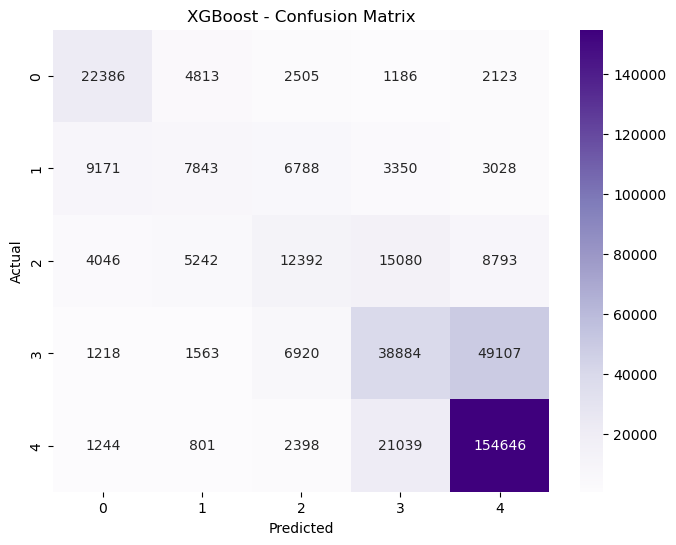

In [30]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------------------------
# Subtract 1 from y_train and y_test so labels start at 0
# (IMPORTANT: do this BEFORE fitting)
y_train_adj = y_train - 1
y_test_adj = y_test - 1

# -------------------------------------------
# Create XGBoost Classifier
xgb = XGBClassifier(
    n_estimators=100,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

# Train
xgb.fit(X_train, y_train_adj)

# Predict
y_pred_xgb = xgb.predict(X_test)

# Print report
print("\n--- XGBoost Classifier ---")
print(classification_report(y_test_adj, y_pred_xgb))

# Confusion Matrix
plt.figure(figsize=(8,6))
sns.heatmap(confusion_matrix(y_test_adj, y_pred_xgb), annot=True, fmt='d', cmap='Purples')
plt.title('XGBoost - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


In [12]:
# ------------------ ADD PREDICTED VS ACTUAL COLUMN ------------------
X_test_copy = X_test.copy()
X_test_copy['Actual'] = y_test.values
X_test_copy['Predicted_RF'] = y_pred_balanced
X_test_copy['Flagged'] = (X_test_copy['Predicted_RF'] < 3).astype(int)


In [10]:
import pandas as pd

# Read the saved dataset
df = pd.read_csv(r"D:\University\Project\Proj\Processed\yelp_reviews_with_fake_review_features.csv")

print("✅ Dataset loaded successfully.")
print(df.shape)
print(df.head())


✅ Dataset loaded successfully.
(1932826, 178)
                review_id                 user_id             business_id  \
0  KU_O5udG6zpxOg-VcAEodg  mh_-eMZ6K5RLWhZyISBhwA  XQfwVwDr-v0ZS3_CbbE5Xw   
1  AqPFMleE6RsU23_auESxiA  _7bHUi9Uuf5__HHc_Q8guQ  kxX2SOes4o-D3ZQBkiMRfA   
2  Sx8TMOWLNuJBWer-0pcmoA  bcjbaE6dDog4jkNY91ncLQ  e4Vwtrqf-wpJfwesgvdgxQ   
3  pUycOfUwM8vqX7KjRRhUEA  59MxRhNVhU9MYndMkz0wtw  gebiRewfieSdtt17PTW6Zg   
4  lUUhg8ltDsUZ9h0xnwY4Dg  RreNy--tOmXMl1en0wiBOg  cPepkJeRMtHapc_b2Oe_dw   

   stars_x  useful  funny  cool  \
0      3.0       0      0     0   
1      5.0       1      0     1   
2      4.0       1      0     1   
3      3.0       0      0     0   
4      4.0       1      0     1   

                                                text                 date  \
0  If you decide to eat here, just be aware it is...  2018-07-07 22:09:11   
1  Wow!  Yummy, different,  delicious.   Our favo...  2015-01-04 00:01:03   
2  Cute interior and owner (?) gave us tour of up

In [3]:
import shap

# Sample 10,000 rows
sample_X = X_test.sample(n=2000, random_state=42)

# TreeExplainer
explainer_rf = shap.TreeExplainer(rf_balanced)

# Compute SHAP values
shap_values = explainer_rf.shap_values(sample_X, check_additivity=False)

# Summary plot
shap.summary_plot(shap_values, sample_X, feature_names=sample_X.columns)


NameError: name 'X_test_scaled' is not defined